# Rolling Average & Time Decay

By Akmal Goldi Bazarghan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display 

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## Part 1 — Feature Engineering: Rolling Average & Temporal Alignment

In [2]:
file_path = '../../data/cleaned/abis_cleaning.csv'
df = pd.read_csv(file_path)

print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   video_id                            2345 non-null   object 
 1   video_title                         2345 non-null   object 
 2   waktu_publikasi_video               2345 non-null   object 
 3   duration                            2345 non-null   float64
 4   engaged_views                       2345 non-null   int64  
 5   estimated_adsense_revenue_idr       2345 non-null   float64
 6   subscriber_yang_diperoleh           2345 non-null   int64  
 7   subscriber_yang_hilang              2345 non-null   int64  
 8   suka                                2345 non-null   int64  
 9   tidak_suka                          2345 non-null   int64  
 10  komentar_ditambahkan                2345 non-null   int64  
 11  average_percentage_viewed_pct

In [3]:
time_part = df['upload_time_wib'].str.split(' ').str[-1]
df['publish_datetime'] = pd.to_datetime(df['tanggal_upload'] + ' ' + time_part)
df = df.sort_values('publish_datetime').reset_index(drop=True)

print("Validasi Pengurutan Waktu:")
print(f"Min Date : {df['publish_datetime'].min()}")
print(f"Max Date : {df['publish_datetime'].max()}")
print(f"Monotonik Naik (Kronologis): {df['publish_datetime'].is_monotonic_increasing}")

Validasi Pengurutan Waktu:
Min Date : 2024-12-01 15:00:06
Max Date : 2026-04-01 13:15:06
Monotonik Naik (Kronologis): True


In [4]:
window_size = 5

df['rolling_avg_views'] = df['views'].rolling(window=window_size, min_periods=1).mean().shift(1).fillna(0)
df['rolling_std_views'] = df['views'].rolling(window=window_size, min_periods=1).std().shift(1).fillna(0)

# Perbaikan Data Leakage: Menghitung EMA dan Rolling Avg 15 untuk trend ratio
df['ema_views_5'] = df['views'].ewm(span=5, min_periods=1).mean().shift(1).fillna(0)
df['rolling_avg_views_15'] = df['views'].rolling(window=15, min_periods=1).mean().shift(1).fillna(0)

df['views_trend_ratio'] = np.where(
    df['rolling_avg_views_15'] == 0, 
    1.0, 
    df['ema_views_5'] / df['rolling_avg_views_15']
)

### 4.1 Validasi Visual: Rolling Average (Leakage Check)
Memastikan nilai rolling mengambil data masa lalu, bukan masa depan.

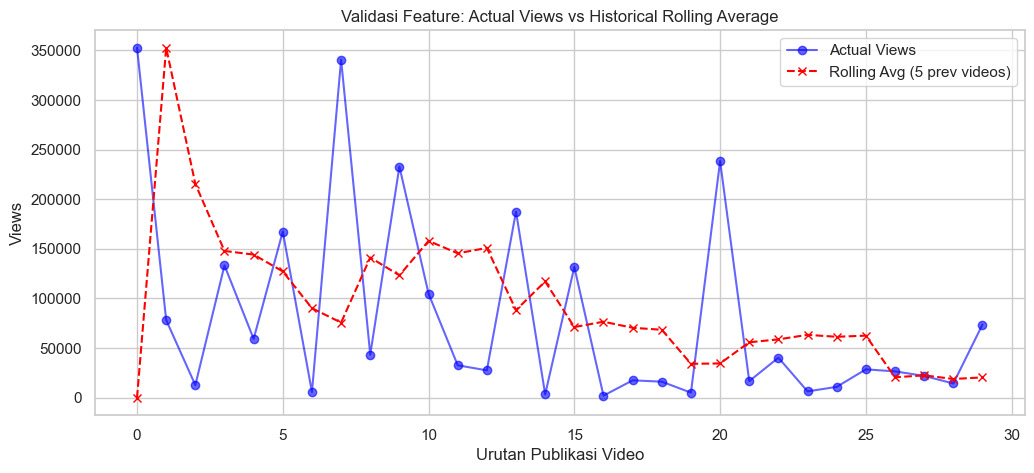

In [5]:
sample = df.head(30) # 30 video pertama untuk sampel

plt.figure(figsize=(12, 5))
plt.plot(sample.index, sample['views'], marker='o', label='Actual Views', color='blue', alpha=0.6)
plt.plot(sample.index, sample['rolling_avg_views'], marker='x', label='Rolling Avg (5 prev videos)', color='red', linestyle='--')
plt.title("Validasi Feature: Actual Views vs Historical Rolling Average")
plt.xlabel("Urutan Publikasi Video")
plt.ylabel("Views")
plt.legend()
plt.show()

## 5. Feature Engineering: Time Decay
Menghitung penyusutan relevansi video berdasarkan waktu menggunakan fungsi eksponensial.

In [6]:
CURRENT_DATE = df['publish_datetime'].max() + pd.Timedelta(days=1)
df['video_age_days'] = (CURRENT_DATE - df['publish_datetime'].dt.normalize()).dt.days

HALF_LIFE = 365  # Video kehilangan 50% relevansi setelah 1 tahun
LAMBDA_DECAY = np.log(2) / HALF_LIFE  # ~0.0019
df['decay_weight'] = np.exp(-LAMBDA_DECAY * df['video_age_days'])

# Perbaikan Data Leakage: Menggunakan historical views (EMA), bukan target views
df['decayed_historical_views'] = df['ema_views_5'] * df['decay_weight']

### 5.1 Validasi Visual: Decay Curve
Memastikan fungsi distribusi bobot meluruh secara eksponensial seiring bertambahnya usia video.

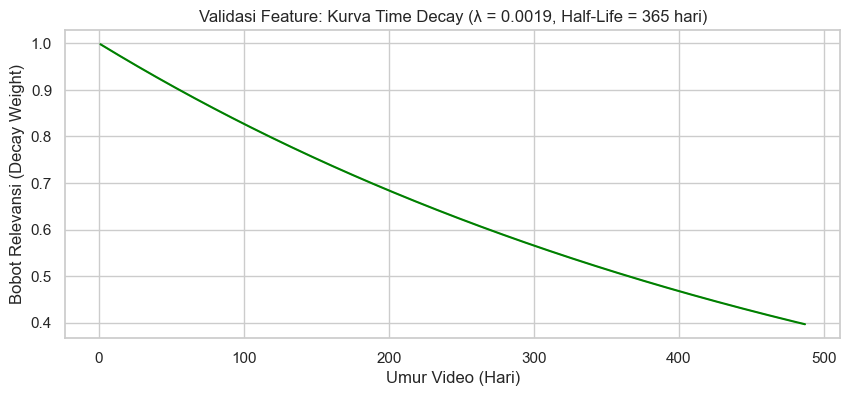

In [7]:
plt.figure(figsize=(10, 4))
sns.lineplot(x='video_age_days', y='decay_weight', data=df, color='green')
plt.title(f"Validasi Feature: Kurva Time Decay (λ = {LAMBDA_DECAY:.4f}, Half-Life = {HALF_LIFE} hari)")
plt.xlabel("Umur Video (Hari)")
plt.ylabel("Bobot Relevansi (Decay Weight)")
plt.show()

## 6. Final Feature Validation & Correlation
Mengecek signifikansi fitur baru terhadap target utama (`views`).

Deskripsi Statistik Fitur Baru:


,rolling_avg_views,rolling_std_views,views_trend_ratio,decay_weight,decayed_historical_views,ema_views_5
count,2345.000000,2345.000000,2345.000000,2345.000000,2345.000000,2345.000000
mean,43592.708223,49824.345039,0.994176,0.675671,25625.966844,43559.484958
std,54049.401342,73488.052753,0.479038,0.168660,30212.124508,53501.079190
min,0.000000,0.000000,0.171330,0.396599,0.000000,0.000000
25%,11224.000000,8806.899443,0.664999,0.536396,8560.975463,11954.786879
50%,25171.200000,22923.244746,0.894389,0.657253,16038.298844,25377.991192
75%,52167.000000,58405.434681,1.202908,0.816118,30778.081887,53352.900189
max,606821.800000,713553.067877,4.100678,0.998103,354977.141978,581611.137137


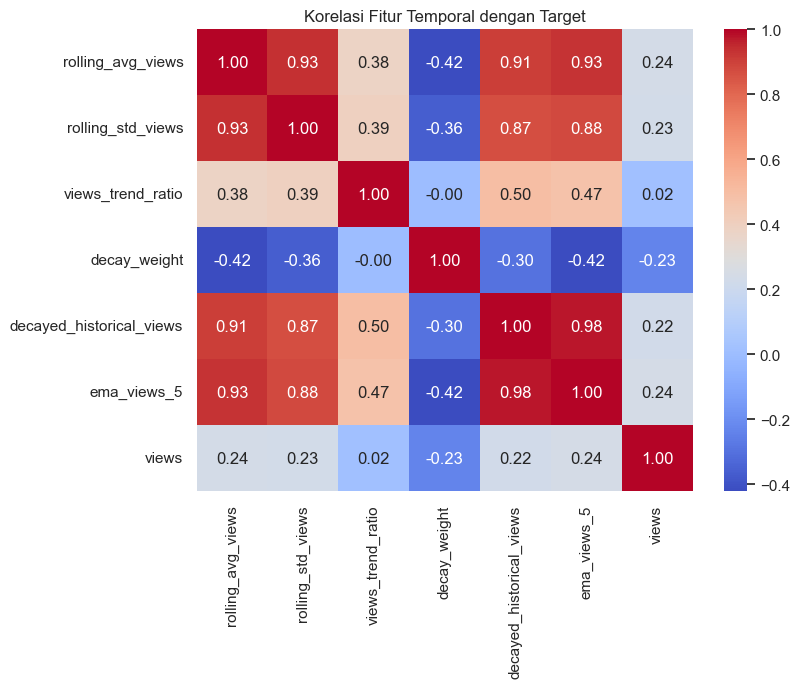

In [8]:
feature_cols = ['rolling_avg_views', 'rolling_std_views', 'views_trend_ratio', 'decay_weight', 'decayed_historical_views', 'ema_views_5']

print("Deskripsi Statistik Fitur Baru:")
display(df[feature_cols].describe())

plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols + ['views']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Fitur Temporal dengan Target")
plt.show()

## Save Data

In [9]:
output_path = '../../data/processed/features_time_decay.csv'

df.to_csv(output_path, index=False)

print(f" Feature Engineering selesai dengan aman!")
print(f" Data diekspor ke: {output_path}")
print(f" Dimensi data final: {df.shape[0]} baris dan {df.shape[1]} kolom.")

 Feature Engineering selesai dengan aman!
 Data diekspor ke: ../../data/processed/features_time_decay.csv
 Dimensi data final: 2345 baris dan 51 kolom.


In [10]:
file_path = '../../data/processed/features_time_decay.csv'
df = pd.read_csv(file_path)

df.head(5)

,video_id,video_title,waktu_publikasi_video,duration,engaged_views,estimated_adsense_revenue_idr,subscriber_yang_diperoleh,subscriber_yang_hilang,suka,tidak_suka,...,views_log,publish_datetime,rolling_avg_views,rolling_std_views,ema_views_5,rolling_avg_views_15,views_trend_ratio,video_age_days,decay_weight,decayed_historical_views
0,PsqlZW8gysU,"AUSTRALIA & INGGRIS PERINGATI HUT OPM, PAPUA S...","Dec 1, 2024",505.0,352554,1140952.151,1363,51,2258,253,...,12.772962,2024-12-01 15:00:06,0.000000,0.000000,0.000000,0.000000,1.000000,487,0.396599,0.000000
1,q4XH6kCddq4,"PAPUA MEMANAS! OPM KLAIM SERANG BRIMOB, POLDA ...","Dec 1, 2024",245.0,78251,127637.487,190,10,463,25,...,11.267690,2024-12-01 19:15:06,352554.000000,0.000000,352554.000000,352554.000000,1.000000,487,0.396599,139822.610332
2,MBi4YbptfKo,PAPUA SIAP MERDEKA? INGGRIS & AUSTRALIA MAKIN ...,"Dec 2, 2024",227.0,12755,28335.144,30,2,79,10,...,9.453757,2024-12-02 11:00:06,215402.500000,193961.511400,187972.200000,215402.500000,0.872656,486,0.397353,74691.318043
3,fUMOF529AwI,"OPM HAMA NKRI, BASMI SAMPAI TAK TERSISA LAGI !","Dec 2, 2024",225.0,133323,316020.438,294,27,1017,31,...,11.800538,2024-12-02 14:50:06,147853.333333,180275.355233,104974.578947,147853.333333,0.709991,486,0.397353,41711.964123
4,tAhvwiVuRYY,INGGRIS DAN AUSTRALIA PENYOKONG KEKACAUAN DI T...,"Dec 2, 2024",291.0,59330,133367.325,150,12,453,16,...,10.990887,2024-12-02 16:00:06,144220.750000,147373.398039,116750.076923,144220.750000,0.809523,486,0.397353,46390.993599


## Summary

### Fitur yang Dihasilkan

Notebook ini menghasilkan 7 fitur temporal yang hanya menggunakan data historis untuk menghindari data leakage.

| Feature | Deskripsi |
|---|---|
| rolling_avg_views | Rata-rata views dari 5 video sebelumnya |
| rolling_std_views | Standar deviasi views dari 5 video sebelumnya |
| ema_views_5 | Exponential Moving Average (span=5) dari views historis |
| rolling_avg_views_15 | Rata-rata views dari 15 video sebelumnya |
| views_trend_ratio | Rasio EMA-5 terhadap Rolling-15 untuk melihat arah tren views |
| decay_weight | Bobot relevansi berdasarkan umur video |
| decayed_historical_views | Nilai historis views setelah diberi penalti waktu |

### Catatan Penting

- Semua fitur rolling dan EMA menggunakan `.shift(1)` agar hanya memakai informasi dari video sebelumnya.
- `views_trend_ratio` dan `decayed_historical_views` diturunkan dari fitur historis sehingga tidak mengambil nilai target secara langsung.
- Pendekatan decay menggunakan konsep half-life:

  λ = ln(2) / 365 ≈ 0.0019

  sehingga kontribusi video lama akan menurun secara bertahap terhadap fitur historis.

### Pertimbangan Modelling

- Terdapat korelasi tinggi antara:
  - `rolling_avg_views`
  - `rolling_std_views`
  - `ema_views_5`

  dengan nilai korelasi sekitar 0.88–0.93.

- Pada tahap modelling, bisa dipertimbangkan:
  - feature selection
  - regularization
  - dimensionality reduction seperti PCA

### Output

Dataset hasil feature engineering diekspor ke:

`data/processed/features_time_decay.csv`

dan akan digabung dengan fitur lain pada tahap agregasi di:

`07_feature_aggregation.ipynb`